In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [15]:
# Loading Data Modelling Libraries
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier ,RandomForestClassifier ,GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import roc_auc_score ,mean_squared_error,accuracy_score,classification_report,roc_curve,confusion_matrix
import warnings
warnings.filterwarnings('ignore')
from scipy.stats.mstats import winsorize
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns',None)
import sys


DATA LOADING


In [24]:
import pandas as pd
df=pd.read_csv('c:/Sakshi/bank.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


DATA PREPROCESSING

In [17]:
# Identify categorical columns in the full DataFrame
categorical_cols_df = df.select_dtypes(include='object').columns.drop('deposit', errors='ignore')

# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(df.drop('deposit', axis=1), columns=categorical_cols_df, drop_first=True)

# Initialize LabelEncoder for the target variable
le_full = LabelEncoder()

# Fit and transform the target variable
y_encoded = le_full.fit_transform(df['deposit'])

print("Encoded Features (X_encoded) Head:")
display(X_encoded.head())
print("\nEncoded Target (y_encoded) Head:")
display(pd.Series(y_encoded).head())

Encoded Features (X_encoded) Head:


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True



Encoded Target (y_encoded) Head:


0    1
1    1
2    1
3    1
4    1
dtype: int32

DATA SPLITTING

In [18]:
x_train_final, x_test_final, y_train_final, y_test_final = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Shape of x_train_final:", x_train_final.shape)
print("Shape of x_test_final:", x_test_final.shape)
print("Shape of y_train_final:", y_train_final.shape)
print("Shape of y_test_final:", y_test_final.shape)

Shape of x_train_final: (8929, 42)
Shape of x_test_final: (2233, 42)
Shape of y_train_final: (8929,)
Shape of y_test_final: (2233,)


TRAIN AND EVALUATE LOGISTIC REGRESSION MODEL

In [19]:
# Initialize Logistic Regression model with increased max_iter for convergence
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the final encoded training data
model_lr.fit(x_train_final, y_train_final)

print("Logistic Regression model trained successfully.")

# Make predictions on the test set
y_pred_lr = model_lr.predict(x_test_final)
print("Predictions made successfully.")

Logistic Regression model trained successfully.
Predictions made successfully.


Accuracy Score: 0.8177

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1175
           1       0.82      0.79      0.81      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233

ROC AUC Score: 0.8166


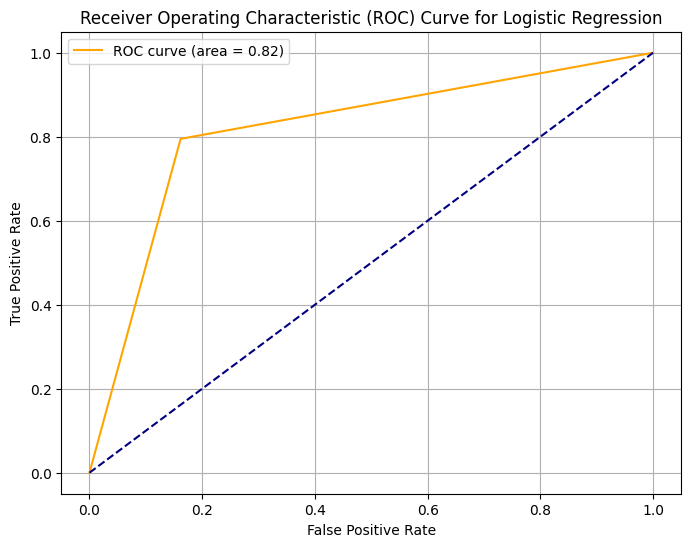

In [20]:
# Calculate Accuracy
accuracy_lr = accuracy_score(y_test_final, y_pred_lr)
print(f"Accuracy Score: {accuracy_lr:.4f}")

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_lr))

# Calculate ROC AUC Score
roc_auc_lr = roc_auc_score(y_test_final, y_pred_lr)
print(f"ROC AUC Score: {roc_auc_lr:.4f}")

# Plot ROC Curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test_final, y_pred_lr)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='orange', label=f'ROC curve (area = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

TRAIN AND EVALUATE RANDOM FOREST CLASSIFIER

In [21]:
# Initialize Random Forest Classifier with best hyperparameters (from previous GridSearch)
model_rf = RandomForestClassifier(criterion='entropy', max_depth=8, max_features='log2', random_state=42)

# Train the model
model_rf.fit(x_train_final, y_train_final)

# Make predictions on the test set
y_pred_rf = model_rf.predict(x_test_final)

print("Random Forest Classifier trained and predictions made successfully.")

Random Forest Classifier trained and predictions made successfully.


Accuracy Score (Random Forest): 0.8383

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1175
           1       0.81      0.86      0.83      1058

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233

ROC AUC Score (Random Forest): 0.8392


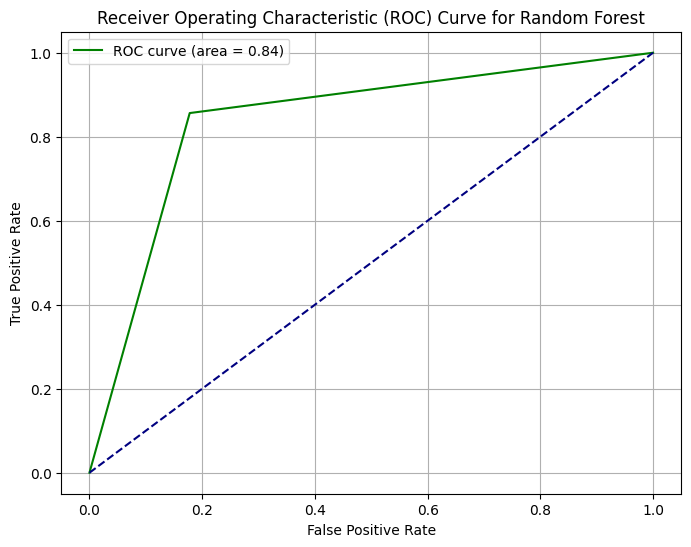

In [22]:
# Calculate Accuracy
accuracy_rf = accuracy_score(y_test_final, y_pred_rf)
print(f"Accuracy Score (Random Forest): {accuracy_rf:.4f}")

# Generate Classification Report
print("\nClassification Report (Random Forest):")
print(classification_report(y_test_final, y_pred_rf))

# Calculate ROC AUC Score
roc_auc_rf = roc_auc_score(y_test_final, y_pred_rf)
print(f"ROC AUC Score (Random Forest): {roc_auc_rf:.4f}")

# Plot ROC Curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_final, y_pred_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend()
plt.grid(True)
plt.show()


ANALYZE AND VISUALIZE FEATURE IMPORTANCE FROM RANDOM FOREST MODEL


Feature Importance Analysis for Random Forest:
Top 10 Most Important Features:


,Feature,Importance
3,duration,0.417027
40,poutcome_success,0.082151
27,contact_unknown,0.063474
0,age,0.045450
5,pdays,0.044711
1,balance,0.038972
24,housing_yes,0.037232
41,poutcome_unknown,0.032861
2,day,0.026967
6,previous,0.026200


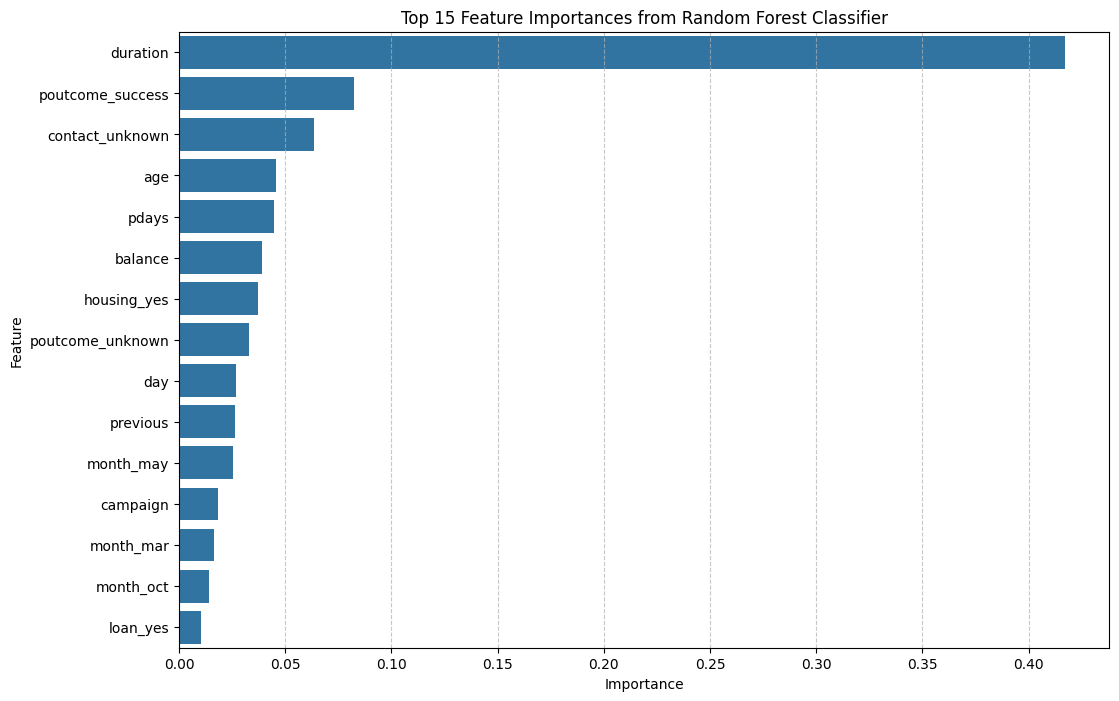

In [23]:
# 6. Analyze and Visualize Feature Importances from Random Forest Model
print("\nFeature Importance Analysis for Random Forest:")
importances = model_rf.feature_importances_
feature_names = x_train_final.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("Top 10 Most Important Features:")
display(feature_importance_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Feature Importances from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Submitted by-

Sakshi Rani(2401021019)

Kritika Sahoo(2401020856)

Smaraki Mohapatra(2401020499)

Kashafun Afroz(2401020915)

Madhusmita Swain(2401020857)